# Cropland analysis

## 1. The Aweil counties
Map of South Sudan with the five Aweil counties (Centre, East, North, South, West) in Northern Bahr el Ghazal outlined.

In [1]:
# Setup
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "raw_data").exists())
ADMIN = REPO / "raw_data" / "Administrative boundaries"

a1 = gpd.read_file(ADMIN / "ssd_admin1.geojson")
a2 = gpd.read_file(ADMIN / "ssd_admin2.geojson")

AWEIL_ALL = ["Aweil Centre", "Aweil East", "Aweil North", "Aweil South", "Aweil West"]
aweil = a2[a2.adm2_name.isin(AWEIL_ALL)]
assert len(aweil) == 5, aweil.adm2_name.tolist()

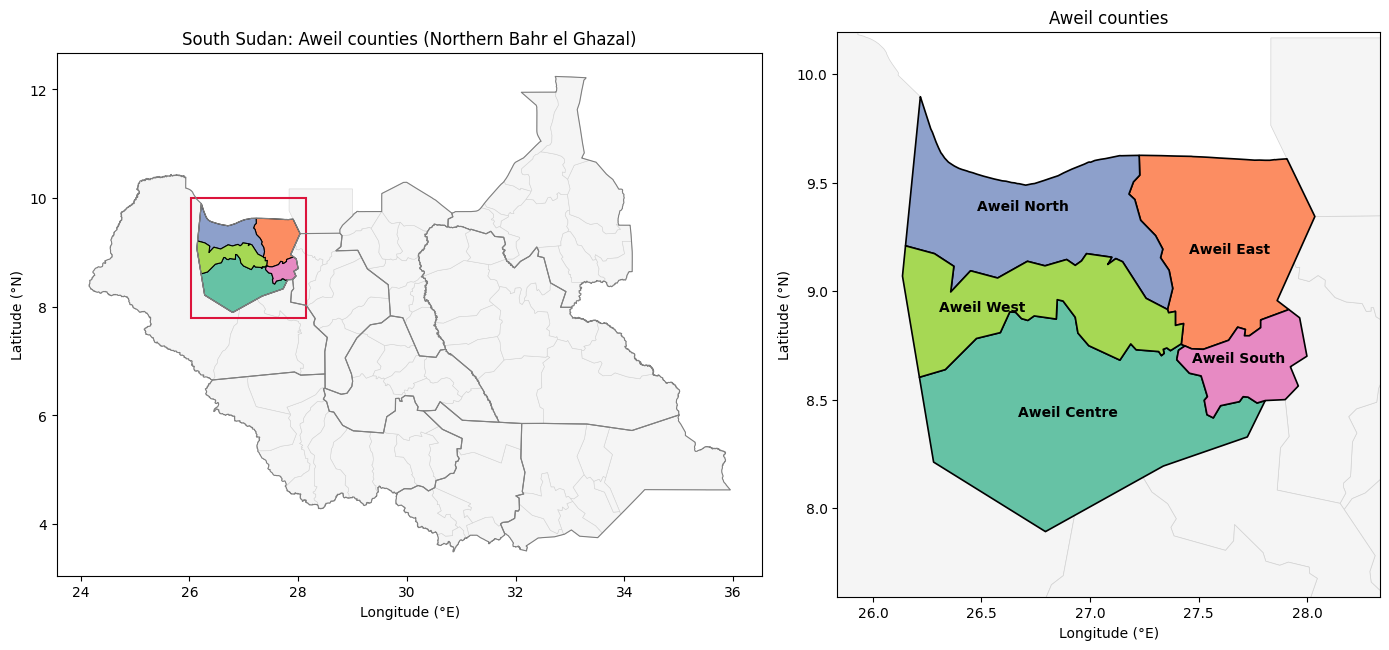

,adm2_name,adm2_pcode,adm1_name,area_sqkm
33,Aweil Centre,SS0501,Northern Bahr el Ghazal,11156.747654
34,Aweil East,SS0502,Northern Bahr el Ghazal,6367.533884
35,Aweil North,SS0503,Northern Bahr el Ghazal,6342.814562
36,Aweil South,SS0504,Northern Bahr el Ghazal,1976.882858
37,Aweil West,SS0505,Northern Bahr el Ghazal,5007.851684


In [2]:
# Map: South Sudan with the Aweil counties outlined (left) and a zoom on Aweil (right)
colors = dict(zip(AWEIL_ALL, plt.cm.Set2.colors))
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 6.5), gridspec_kw={"width_ratios": [1.3, 1]})

# Left: national overview
a2.plot(ax=ax0, facecolor="whitesmoke", edgecolor="lightgrey", linewidth=0.4)
a1.boundary.plot(ax=ax0, color="grey", linewidth=0.8)
aweil.plot(ax=ax0, color=aweil.adm2_name.map(colors), edgecolor="black", linewidth=0.8)
minx, miny, maxx, maxy = aweil.total_bounds
ax0.add_patch(plt.Rectangle((minx - 0.1, miny - 0.1), maxx - minx + 0.2, maxy - miny + 0.2,
                            fill=False, edgecolor="crimson", linewidth=1.5))
ax0.set_title("South Sudan: Aweil counties (Northern Bahr el Ghazal)")

# Right: zoom on the Aweil counties with neighbouring counties as context
a2.plot(ax=ax1, facecolor="whitesmoke", edgecolor="lightgrey", linewidth=0.5)
aweil.plot(ax=ax1, color=aweil.adm2_name.map(colors), edgecolor="black", linewidth=1.2)
for _, r in aweil.iterrows():
    p = r.geometry.representative_point()
    ax1.annotate(r.adm2_name, (p.x, p.y), ha="center", fontsize=10, weight="bold")
ax1.set_xlim(minx - 0.3, maxx + 0.3)
ax1.set_ylim(miny - 0.3, maxy + 0.3)
ax1.set_title("Aweil counties")

for ax in (ax0, ax1):
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

aweil[["adm2_name", "adm2_pcode", "adm1_name", "area_sqkm"]].sort_values("adm2_name")

## 2. Cropland mask for Aweil
ASAP v04 crop mask (JRC, Dec 2023, ~0.0045° ≈ 500 m pixels). Each pixel holds the % of its area under crops (0-100). Clipped to the five Aweil counties; cropland area per county = sum of (crop fraction × pixel area).

In [3]:
# Load the crop mask for the Aweil bounding box and clip it to the county polygons
import numpy as np
import pandas as pd
import rioxarray as rxr

CROP_TIF = REPO / "raw_data" / "farmland" / "asap_mask_crop_v04.tif"
minx, miny, maxx, maxy = aweil.total_bounds

crop = rxr.open_rasterio(CROP_TIF)
crop = crop.squeeze("band", drop=True).rio.clip_box(minx, miny, maxx, maxy)
print("unique values outside 0-100:", np.unique(crop.values[crop.values > 100]))
crop = crop.where(crop <= 100).astype("float32")  # anything >100 is fill, not a percentage

# Per-county clip; pixel area in km2 varies with latitude
res = abs(crop.rio.resolution()[0])
lat = crop.y.values
pix_km2 = (res * 111.32) ** 2 * np.cos(np.deg2rad(lat))[:, None] * np.ones(crop.shape)
pix_km2 = crop.copy(data=pix_km2)

rows, crop_by_county = [], {}
for _, r in aweil.iterrows():
    c = crop.rio.clip([r.geometry], aweil.crs, drop=False)
    crop_by_county[r.adm2_name] = c
    frac = (c / 100).fillna(0)
    rows.append({
        "county": r.adm2_name,
        "county_km2": r.area_sqkm,
        "cropland_km2": float((frac * pix_km2).sum()),
        "pixels_with_crop": int((c > 0).sum()),
    })
crop_aweil = crop.rio.clip(aweil.geometry, aweil.crs, drop=False)

crop_tab = pd.DataFrame(rows).set_index("county").sort_index()
crop_tab["cropland_%"] = 100 * crop_tab.cropland_km2 / crop_tab.county_km2
crop_tab.loc["Aweil total"] = crop_tab.sum(numeric_only=True)
crop_tab.loc["Aweil total", "cropland_%"] = 100 * crop_tab.loc["Aweil total", "cropland_km2"] / crop_tab.loc["Aweil total", "county_km2"]
crop_tab.round(1)

unique values outside 0-100: []


,county_km2,cropland_km2,pixels_with_crop,cropland_%
county,,,,
Aweil Centre,11156.7,3.9,416.0,0.0
Aweil East,6367.5,191.4,6940.0,3.0
Aweil North,6342.8,42.5,2649.0,0.7
Aweil South,1976.9,34.7,1790.0,1.8
Aweil West,5007.9,25.4,1710.0,0.5
Aweil total,30851.8,298.0,13505.0,1.0


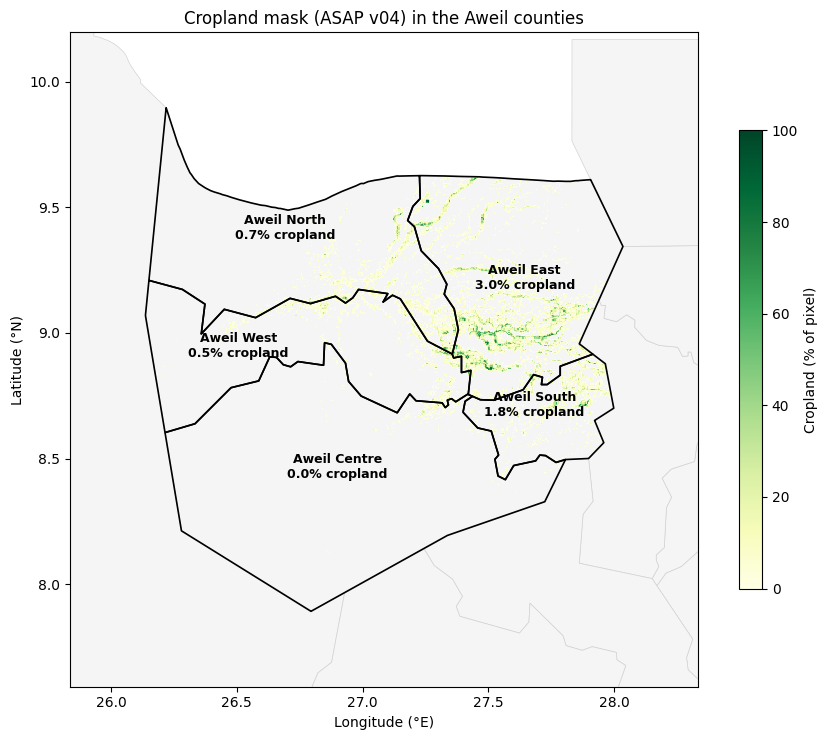

In [4]:
# Map: crop fraction inside the Aweil counties
fig, ax = plt.subplots(figsize=(9, 7.5))
a2.plot(ax=ax, facecolor="whitesmoke", edgecolor="lightgrey", linewidth=0.5)
im = crop_aweil.where(crop_aweil > 0).plot(ax=ax, cmap="YlGn", vmin=0, vmax=100, add_colorbar=False)
aweil.boundary.plot(ax=ax, color="black", linewidth=1.2)
for _, r in aweil.iterrows():
    p = r.geometry.representative_point()
    ax.annotate(f"{r.adm2_name}\n{crop_tab.loc[r.adm2_name, 'cropland_%']:.1f}% cropland", (p.x, p.y),
                ha="center", fontsize=9, weight="bold")
fig.colorbar(im, ax=ax, shrink=0.7, label="Cropland (% of pixel)")
ax.set_xlim(minx - 0.3, maxx + 0.3)
ax.set_ylim(miny - 0.3, maxy + 0.3)
ax.set_aspect("equal")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("Cropland mask (ASAP v04) in the Aweil counties")
plt.tight_layout()
plt.show()

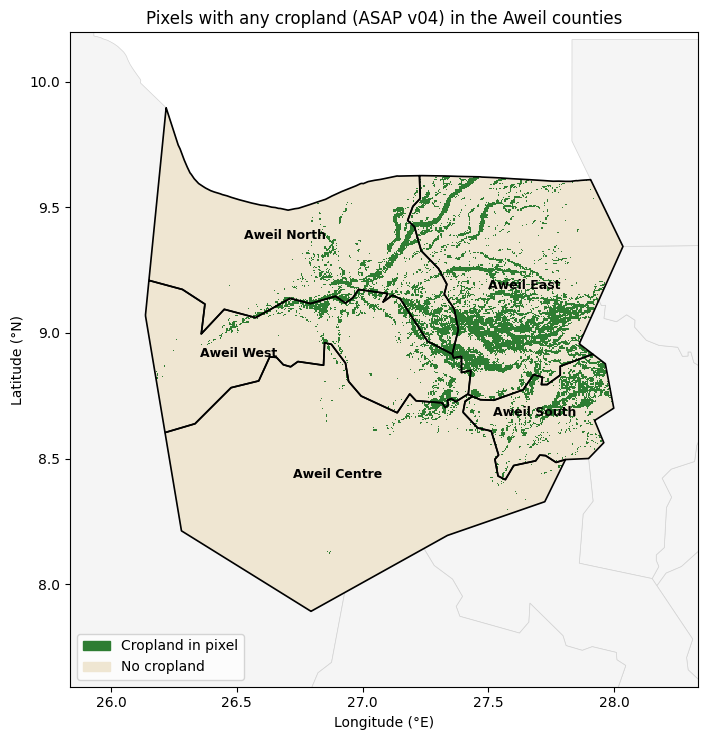

In [5]:
# Map: binary version - does the pixel contain any cropland (>0%) or not
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

has_crop = (crop_aweil > 0).where(crop_aweil.notnull())  # 1 = cropland, 0 = none, NaN = outside Aweil
fig, ax = plt.subplots(figsize=(9, 7.5))
a2.plot(ax=ax, facecolor="whitesmoke", edgecolor="lightgrey", linewidth=0.5)
has_crop.plot(ax=ax, cmap=ListedColormap(["#efe6d2", "#2e7d32"]), vmin=0, vmax=1, add_colorbar=False)
aweil.boundary.plot(ax=ax, color="black", linewidth=1.2)
for _, r in aweil.iterrows():
    p = r.geometry.representative_point()
    ax.annotate(r.adm2_name, (p.x, p.y), ha="center", fontsize=9, weight="bold")
ax.legend(handles=[Patch(color="#2e7d32", label="Cropland in pixel"),
                   Patch(color="#efe6d2", label="No cropland")], loc="lower left")
ax.set_xlim(minx - 0.3, maxx + 0.3)
ax.set_ylim(miny - 0.3, maxy + 0.3)
ax.set_aspect("equal")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("Pixels with any cropland (ASAP v04) in the Aweil counties")
plt.tight_layout()
plt.show()

## 3. Share of cropland flooded per month
For every month: % of Aweil's cropland (km², weighted by crop %) that was flooded at least once that month.

- **Flood data:** MODIS 3-day flood masks (`raw_data/flood_masks`), recurring + unusual combined, ~0.00208° (~230 m) pixels.
- **Flooded in a month:** a flood pixel counts if it is detected at least once in that month.
- **Partial crop pixels:** each crop pixel (~0.00446°) contains ~4-6 flood-pixel centres. Its flooded share = flooded flood pixels / all flood pixels inside it.
- **Cropland flooded (km²)** = Σ flooded share × crop fraction × pixel area. Divided by the county's total cropland km² from section 2.

Caveats: detections jump after ~2018 (sensor change, see `data_exploration.ipynb`), clouds hide rainy-season floods, and the 2023 season is nearly empty.

In [6]:
# Build the monthly flooded-cropland table
import sys
sys.path.insert(0, str(REPO / "processing_data"))
from loading import load_flood_masks

YEARS = np.arange(2000, 2026)
RES_F = 10 / 4800                       # flood-mask pixel size (MODIS tile = 10 deg / 4800 px)
res_c = abs(crop.rio.resolution()[0])   # crop-mask pixel size
x_edge = float(crop.x[0]) - res_c / 2   # left edge of the crop grid
y_edge = float(crop.y[0]) + res_c / 2   # top edge (y runs north -> south)
n_rows, n_cols = crop.shape


def to_crop_cell(lon, lat):
    """Row/column of the crop pixel containing each point; -1 if outside the crop grid."""
    col = np.floor((np.asarray(lon) - x_edge) / res_c).astype(int)
    row = np.floor((y_edge - np.asarray(lat)) / res_c).astype(int)
    out = (col < 0) | (col >= n_cols) | (row < 0) | (row >= n_rows)
    return np.where(out, -1, row), np.where(out, -1, col)


# Total number of flood-pixel centres inside each crop pixel (denominator of the partial share)
f_lon = np.arange(np.floor(minx / RES_F), np.ceil(maxx / RES_F) + 1) * RES_F + RES_F / 2
f_lat = np.arange(np.floor(miny / RES_F), np.ceil(maxy / RES_F) + 1) * RES_F + RES_F / 2
LON, LAT = np.meshgrid(f_lon, f_lat)
r, c = to_crop_cell(LON.ravel(), LAT.ravel())
keep = r >= 0
n_total = np.zeros(crop.shape)
np.add.at(n_total, (r[keep], c[keep]), 1)

# Flood detections in the Aweil box -> unique (month, flood pixel)
bbox = {"lon_min": minx, "lon_max": maxx, "lat_min": miny, "lat_max": maxy}
fl = load_flood_masks(YEARS, bbox=bbox)
fl["month"] = pd.to_datetime(fl["date"].astype(str)).dt.to_period("M")
fl = fl.drop_duplicates(["month", "lat", "lon"])
fl["row"], fl["col"] = to_crop_cell(fl.lon.values, fl.lat.values)
fl = fl[fl.row >= 0]

# Flooded share of each crop pixel per month
fc = fl.groupby(["month", "row", "col"]).size().rename("n_flooded").reset_index()
fc["share"] = np.minimum(fc.n_flooded / n_total[fc.row, fc.col], 1)

# Cropland km2 per crop pixel, per county (0 outside the county)
crop_km2 = {k: ((v / 100) * pix_km2).fillna(0).values for k, v in crop_by_county.items()}
for county, w in crop_km2.items():
    fc[county] = fc.share * w[fc.row, fc.col]

all_months = pd.period_range(f"{YEARS[0]}-01", f"{YEARS[-1]}-12", freq="M")
flooded_km2 = fc.groupby("month")[AWEIL_ALL].sum().reindex(all_months, fill_value=0)
flooded_km2["Aweil total"] = flooded_km2[AWEIL_ALL].sum(axis=1)
flooded_pct = 100 * flooded_km2 / crop_tab.loc[flooded_km2.columns, "cropland_km2"]
flooded_pct.index.name = "month"

# Months before the first flood file date carry no information, not "no flooding"
print("first detection:", fl.month.min(), "| last:", fl.month.max())
flooded_pct.round(2).tail(24)

first detection: 2000-10 | last: 2025-12


,Aweil Centre,Aweil East,Aweil North,Aweil South,Aweil West,Aweil total
month,,,,,,
2024-01,0.0,0.00,0.00,0.00,0.00,0.00
2024-02,0.0,0.00,0.00,0.00,0.00,0.00
2024-03,0.0,0.00,0.00,0.00,0.00,0.00
2024-04,0.0,0.00,0.00,0.00,0.00,0.00
2024-05,0.0,0.00,0.00,0.00,0.00,0.00
2024-06,0.0,0.00,0.00,0.00,0.00,0.00
2024-07,0.0,0.00,0.00,0.00,0.00,0.00
2024-08,0.0,0.00,0.00,0.00,0.00,0.00
2024-09,0.0,0.22,0.15,1.57,0.64,0.40


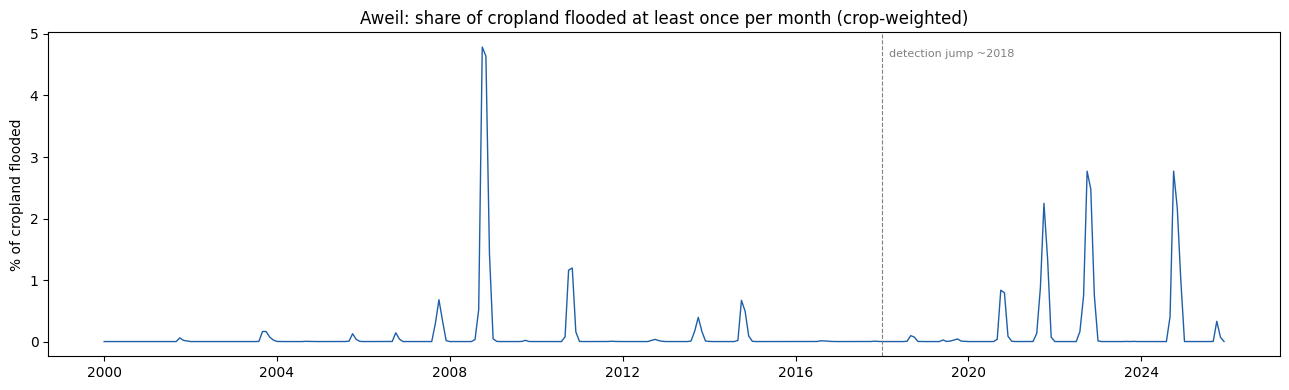

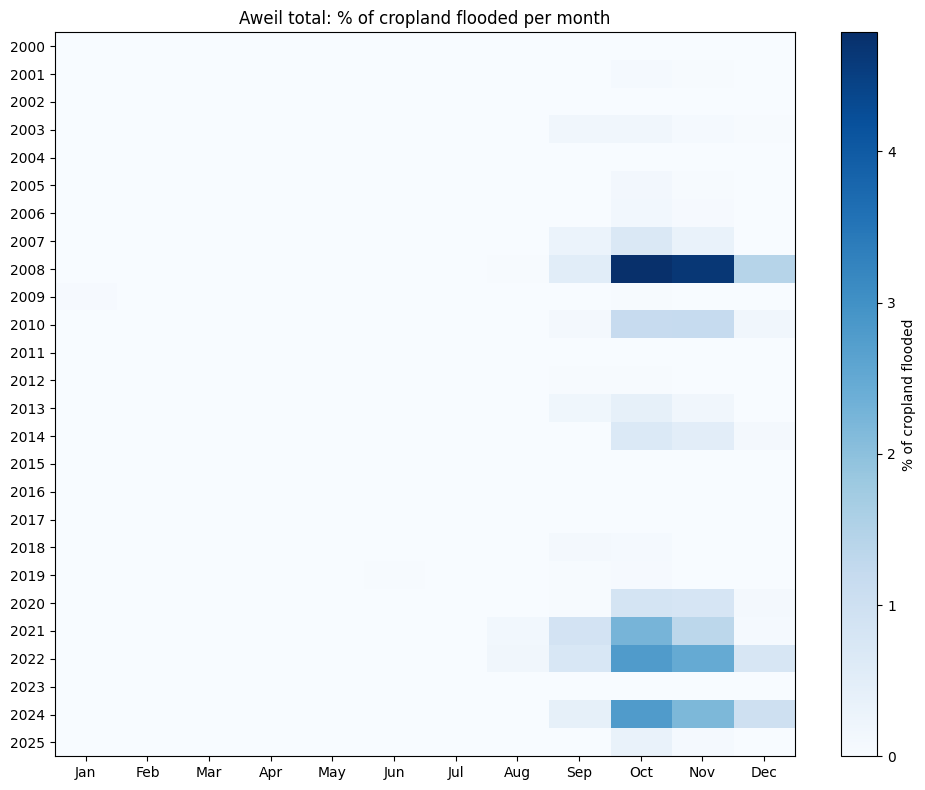

,Aweil Centre,Aweil East,Aweil North,Aweil South,Aweil West,Aweil total
month,,,,,,
2000,0.0,0.0,0.0,0.0,0.0,0.0
2001,0.0,0.0,0.0,0.4,0.0,0.1
2002,0.0,0.0,0.0,0.0,0.0,0.0
2003,0.0,0.1,0.0,0.8,0.1,0.2
2004,0.0,0.0,0.0,0.0,0.0,0.0
2005,0.0,0.2,0.0,0.2,0.0,0.1
2006,0.0,0.1,0.2,0.3,0.1,0.1
2007,0.2,0.6,0.4,0.5,2.7,0.7
2008,0.2,4.9,0.3,13.7,1.5,4.8


In [7]:
# Plots: monthly time series and a year x month heatmap for Aweil total
fig, ax = plt.subplots(figsize=(13, 4))
s = flooded_pct["Aweil total"]
ax.plot(s.index.to_timestamp(), s.values, color="#1f5fa8", linewidth=1)
ax.set_ylabel("% of cropland flooded")
ax.set_title("Aweil: share of cropland flooded at least once per month (crop-weighted)")
ax.axvline(pd.Timestamp("2018-01-01"), color="grey", linestyle="--", linewidth=0.8)
ax.text(pd.Timestamp("2018-03-01"), ax.get_ylim()[1] * 0.92, "detection jump ~2018", color="grey", fontsize=8)
plt.tight_layout()
plt.show()

heat = s.to_frame("pct").assign(year=s.index.year, mon=s.index.month).pivot(index="year", columns="mon", values="pct")
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heat.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(12), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_yticks(range(len(heat)), heat.index)
fig.colorbar(im, ax=ax, label="% of cropland flooded")
ax.set_title("Aweil total: % of cropland flooded per month")
plt.tight_layout()
plt.show()

# Per county: yearly peak month
flooded_pct.groupby(flooded_pct.index.year).max().round(1)

## 4. Cropland vs whole county: is cropland flooded more or less than the land around it?
Same method as section 3, but every pixel inside the county is weighted by its full area instead of its crop %.
- **county flooded %** = flooded area / county area (both on the crop grid)
- **ratio** = cropland flooded % / county flooded %. Below 1: cropland floods less than the county as a whole.

In [8]:
# Whole-county flooded share, same grid and partial-pixel method as section 3
area_km2 = {k: (v.notnull() * pix_km2).values for k, v in crop_by_county.items()}
for county, w in area_km2.items():
    fc[f"{county} area"] = fc.share * w[fc.row, fc.col]

area_cols = [f"{k} area" for k in AWEIL_ALL]
county_flooded_km2 = fc.groupby("month")[area_cols].sum().reindex(all_months, fill_value=0)
county_flooded_km2.columns = AWEIL_ALL
county_flooded_km2["Aweil total"] = county_flooded_km2[AWEIL_ALL].sum(axis=1)
county_area = pd.Series({k: w.sum() for k, w in area_km2.items()})
county_area["Aweil total"] = county_area.sum()
county_pct = 100 * county_flooded_km2 / county_area
county_pct.index.name = "month"

# Yearly peak month and Sep-Dec mean, cropland vs county
yr = flooded_pct.index.year
comp = pd.concat({
    "cropland peak %": flooded_pct.groupby(yr).max(),
    "county peak %": county_pct.groupby(yr).max(),
}, axis=1)

# Overall ratio per county over all months (km2-weighted, so empty months do not distort it)
overall = pd.DataFrame({
    "cropland flooded % (mean month)": flooded_pct.mean(),
    "county flooded % (mean month)": county_pct.mean(),
})
overall["ratio cropland / county"] = overall.iloc[:, 0] / overall.iloc[:, 1]
overall.round(3)

,cropland flooded % (mean month),county flooded % (mean month),ratio cropland / county
Aweil Centre,0.005,0.020,0.267
Aweil East,0.096,0.261,0.367
Aweil North,0.036,0.016,2.193
Aweil South,0.419,0.402,1.041
Aweil West,0.105,0.082,1.273
Aweil total,0.124,0.104,1.201


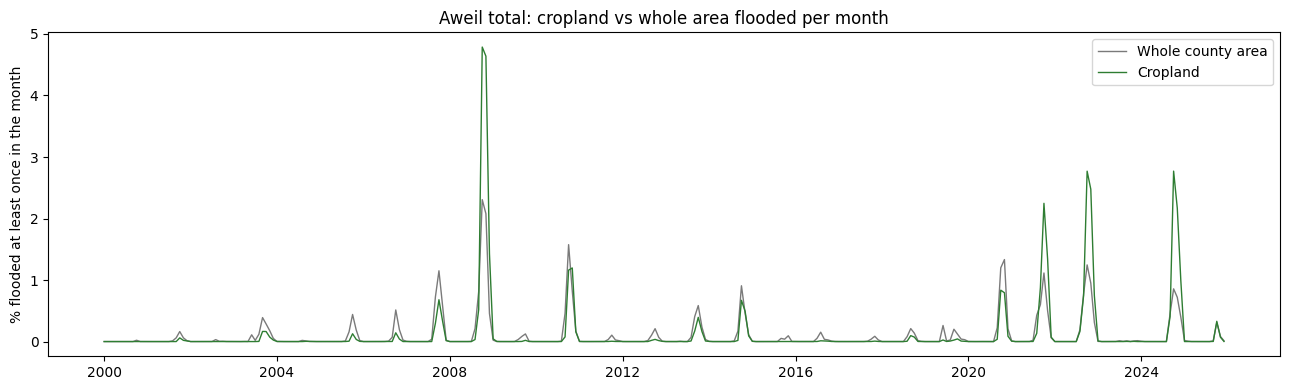

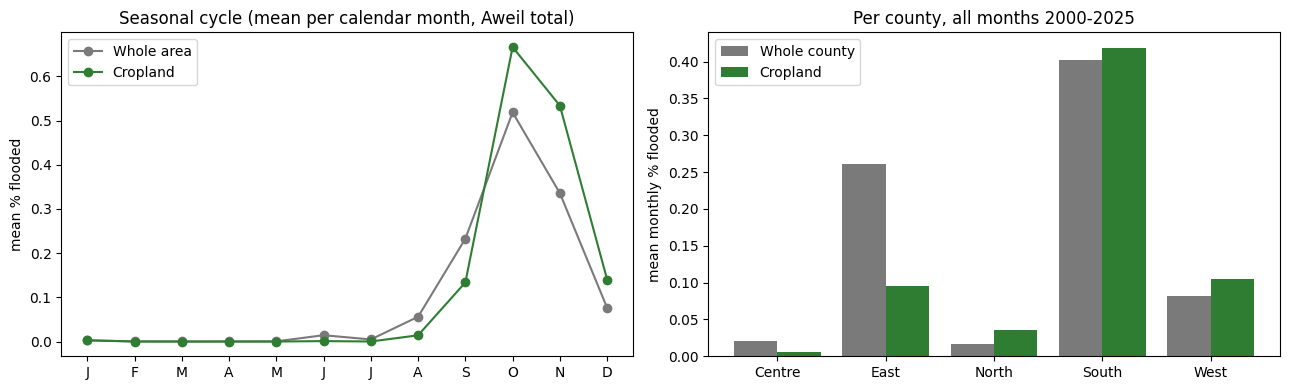

cropland peak %                                                \
         Aweil Centre Aweil East Aweil North Aweil South Aweil West   
month                                                                 
2000             0.00       0.00        0.00        0.00       0.00   
2001             0.00       0.02        0.00        0.41       0.00   
2002             0.00       0.00        0.00        0.01       0.00   
2003             0.00       0.11        0.00        0.79       0.07   
2004             0.00       0.01        0.00        0.00       0.00   
2005             0.03       0.17        0.00        0.15       0.01   
2006             0.00       0.12        0.17        0.25       0.12   
2007             0.17       0.57        0.39        0.53       2.68   
2008             0.18       4.90        0.28       13.68       1.50   
2009             0.00       0.03        0.00        0.34       0.01   
2010             0.27       1.27        1.14        3.24       3.26   
2011             0.00       0.01        0.01        0.01       0.02   
2012             0.02       0.05        0.02        0.10       0.00   
2013             0.00       0.41        0.00        1.06       0.07   
2014             0.00       0.71        0.01        2.53       0.21   
2015             0.00       0.00        0.00        0.04       0.00   
2016             0.00       0.01        0.00        0.05       0.04   
2017             0.00       0.00        0.00        0.05       0.01   
2018             0.00       0.14        0.01        0.17       0.03   
2019             0.00       0.06        0.05        0.02       0.22   
2020             0.29       1.04        1.04        0.66       4.80   
2021             0.00       1.74        0.14        9.22       0.38   
2022             0.00       1.53        2.84       12.38       3.49   
2023             0.16       0.01        0.00        0.05       0.00   
2024             0.00       2.25        0.65        9.28       1.81   
2025             0.00       0.05        0.84        0.19       2.09   

                  county peak %                                                \
      Aweil total  Aweil Centre Aweil East Aweil North Aweil South Aweil West   
month                                                                           
2000         0.00          0.05       0.01        0.00        0.01       0.00   
2001         0.06          0.01       0.50        0.06        0.65       0.03   
2002         0.00          0.01       0.15        0.00        0.01       0.00   
2003         0.16          0.05       1.16        0.11        1.37       0.29   
2004         0.00          0.00       0.09        0.00        0.07       0.00   
2005         0.13          0.08       1.37        0.01        2.18       0.08   
2006         0.14          0.17       1.64        0.05        0.80       0.32   
2007         0.68          0.30       2.95        0.29        1.73       2.04   
2008         4.79          0.52       6.48        0.24        8.82       1.24   
2009         0.04          0.04       0.48        0.01        0.30       0.14   
2010         1.20          0.92       2.84        0.35        3.77       2.57   
2011         0.01          0.01       0.43        0.00        0.34       0.08   
2012         0.04          0.02       0.78        0.00        0.89       0.03   
2013         0.39          0.09       1.92        0.02        2.29       0.23   
2014         0.67          0.04       2.98        0.03        3.20       0.41   
2015         0.00          0.08       0.23        0.00        0.06       0.10   
2016         0.01          0.11       0.35        0.00        0.28       0.23   
2017         0.01          0.01       0.11        0.00        1.02       0.01   
2018         0.10          0.00       0.85        0.08        0.36       0.12   
2019         0.04          0.02       0.82        0.12        0.26       1.13   
2020         0.84          0.66       4.43        0.54        3.66       2.36   
20

In [9]:
# Plots: Aweil total monthly series, seasonal cycle, and yearly peaks per county
fig, ax = plt.subplots(figsize=(13, 4))
t = flooded_pct.index.to_timestamp()
ax.plot(t, county_pct["Aweil total"], color="#7a7a7a", linewidth=1, label="Whole county area")
ax.plot(t, flooded_pct["Aweil total"], color="#2e7d32", linewidth=1, label="Cropland")
ax.set_ylabel("% flooded at least once in the month")
ax.set_title("Aweil total: cropland vs whole area flooded per month")
ax.legend()
plt.tight_layout()
plt.show()

mon = flooded_pct.index.month
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(range(1, 13), county_pct["Aweil total"].groupby(mon).mean(), "o-", color="#7a7a7a", label="Whole area")
axes[0].plot(range(1, 13), flooded_pct["Aweil total"].groupby(mon).mean(), "o-", color="#2e7d32", label="Cropland")
axes[0].set_xticks(range(1, 13), ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
axes[0].set_ylabel("mean % flooded")
axes[0].set_title("Seasonal cycle (mean per calendar month, Aweil total)")
axes[0].legend()

x = np.arange(len(AWEIL_ALL))
axes[1].bar(x - 0.2, overall.loc[AWEIL_ALL].iloc[:, 1], 0.4, color="#7a7a7a", label="Whole county")
axes[1].bar(x + 0.2, overall.loc[AWEIL_ALL].iloc[:, 0], 0.4, color="#2e7d32", label="Cropland")
axes[1].set_xticks(x, [c.replace("Aweil ", "") for c in AWEIL_ALL])
axes[1].set_ylabel("mean monthly % flooded")
axes[1].set_title("Per county, all months 2000-2025")
axes[1].legend()
plt.tight_layout()
plt.show()

comp.round(2)

## 5. Split by flood type: recurring vs unusual
`flood_type` 0 = recurring (water detected in roughly ≥1/3 of years at that pixel), 1 = unusual. Same method as sections 3-4, run per type: a pixel counts for a type if that type is detected at least once in the month.
A pixel can have both types in one month, so recurring + unusual can be slightly more than the combined numbers of sections 3-4.

In [10]:
# Monthly % flooded per flood type, for cropland and for the whole county
TYPES = {0: "recurring", 1: "unusual"}
fl_t = load_flood_masks(YEARS, bbox=bbox)
fl_t["month"] = pd.to_datetime(fl_t["date"].astype(str)).dt.to_period("M")
fl_t = fl_t.drop_duplicates(["month", "flood_type", "lat", "lon"])
fl_t["row"], fl_t["col"] = to_crop_cell(fl_t.lon.values, fl_t.lat.values)
fl_t = fl_t[fl_t.row >= 0]


def pct_flooded(fc_type, weights, denom):
    """% of `denom` flooded per month and county, given per-pixel weights (km2) per county."""
    out = pd.DataFrame({k: fc_type.share * w[fc_type.row, fc_type.col] for k, w in weights.items()})
    out["month"] = fc_type.month.values
    km2 = out.groupby("month")[AWEIL_ALL].sum().reindex(all_months, fill_value=0)
    km2["Aweil total"] = km2[AWEIL_ALL].sum(axis=1)
    return 100 * km2 / denom


crop_by_type, county_by_type = {}, {}
for t, name in TYPES.items():
    ft = fl_t[fl_t.flood_type == t].groupby(["month", "row", "col"]).size().rename("n_flooded").reset_index()
    ft["share"] = np.minimum(ft.n_flooded / n_total[ft.row, ft.col], 1)
    crop_by_type[name] = pct_flooded(ft, crop_km2, crop_tab.loc[AWEIL_ALL + ["Aweil total"], "cropland_km2"])
    county_by_type[name] = pct_flooded(ft, area_km2, county_area)

# Mean monthly % flooded per county, by type, and the cropland / county ratio per type
by_type = pd.concat({
    (name, what): df.mean()
    for name in TYPES.values()
    for what, df in [("cropland %", crop_by_type[name]), ("county %", county_by_type[name])]
}, axis=1)
for name in TYPES.values():
    by_type[(name, "ratio")] = by_type[(name, "cropland %")] / by_type[(name, "county %")]
by_type = by_type.sort_index(axis=1, level=0, sort_remaining=False)
by_type.round(3)

recurring                    unusual                
             cropland % county %  ratio cropland % county %  ratio
Aweil Centre      0.000    0.003  0.000      0.005    0.017  0.311
Aweil East        0.015    0.126  0.120      0.081    0.135  0.598
Aweil North       0.000    0.002  0.039      0.036    0.014  2.456
Aweil South       0.072    0.162  0.444      0.347    0.241  1.442
Aweil West        0.006    0.010  0.629      0.098    0.072  1.361
Aweil total       0.019    0.039  0.474      0.106    0.064  1.647

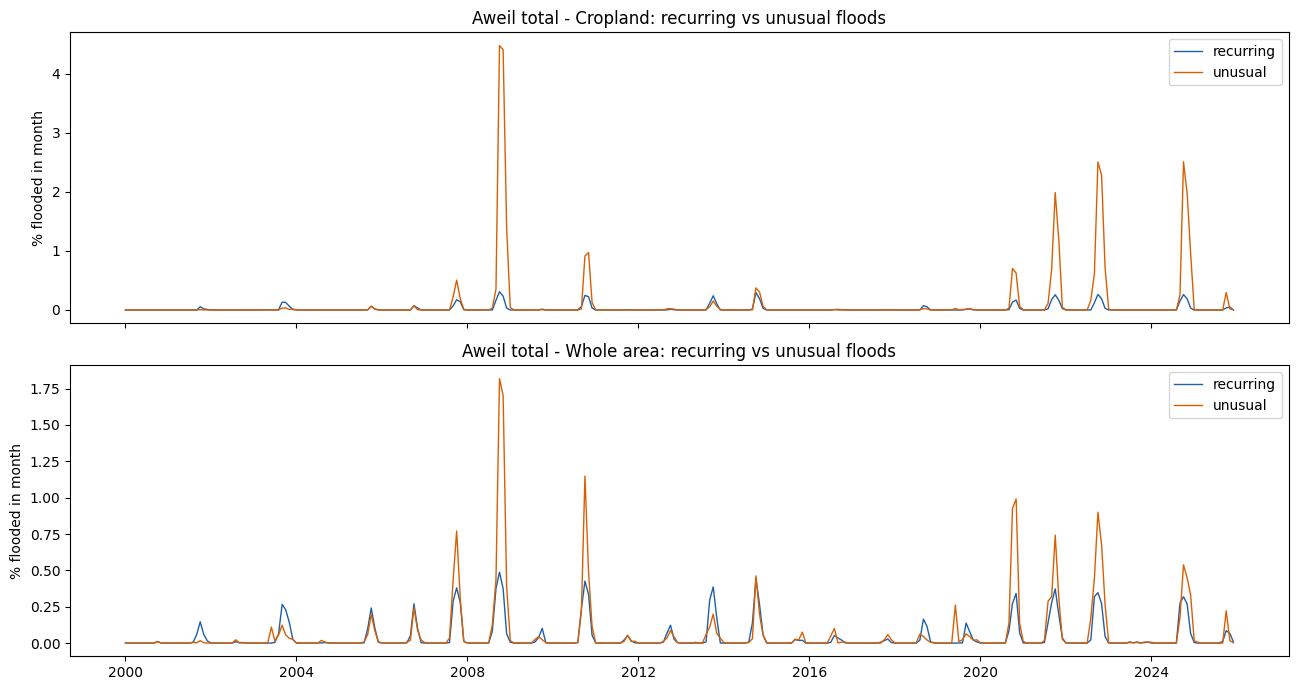

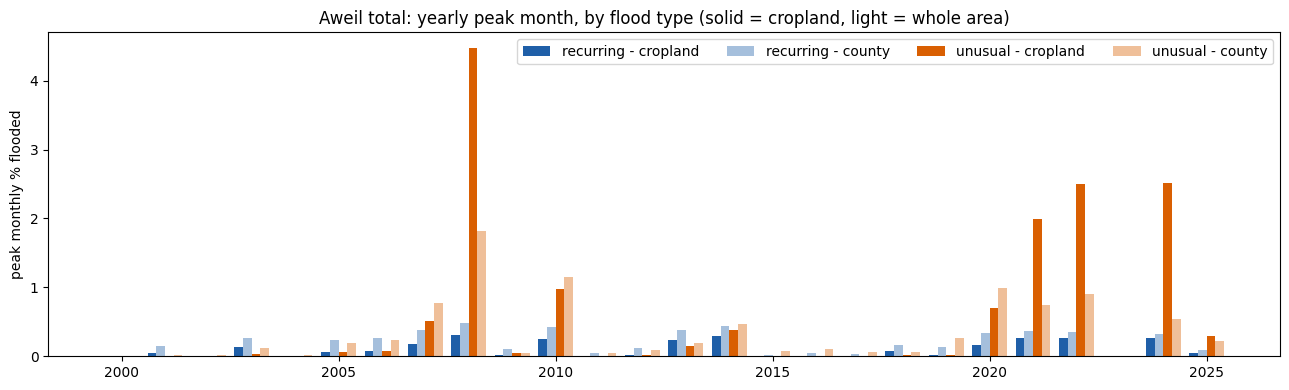

recurring         unusual       
       cropland county cropland county
month                                 
2000       0.00   0.01     0.00   0.01
2001       0.05   0.15     0.01   0.02
2002       0.00   0.01     0.00   0.02
2003       0.13   0.27     0.04   0.12
2004       0.00   0.00     0.00   0.02
2005       0.06   0.24     0.06   0.20
2006       0.07   0.27     0.07   0.24
2007       0.17   0.38     0.51   0.77
2008       0.31   0.49     4.48   1.82
2009       0.01   0.10     0.04   0.04
2010       0.25   0.43     0.97   1.15
2011       0.00   0.05     0.00   0.05
2012       0.01   0.12     0.02   0.09
2013       0.24   0.39     0.15   0.20
2014       0.30   0.44     0.37   0.46
2015       0.00   0.02     0.00   0.07
2016       0.01   0.05     0.01   0.10
2017       0.00   0.03     0.01   0.06
2018       0.07   0.16     0.02   0.06
2019       0.02   0.14     0.03   0.26
2020       0.17   0.34     0.70   0.99
2021       0.26   0.37     1.99   0.74
2022       0.26   0.35     2.51   0.90
2023       0.00   0.01     0.01   0.01
2024       0.26   0.32     2.51   0.54
2025       0.05   0.09     0.30   0.22

In [11]:
# Plots: Aweil total per type over time, and the yearly peak month per type
colors_t = {"recurring": "#1f5fa8", "unusual": "#d95f02"}
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, (label, data) in zip(axes, [("Cropland", crop_by_type), ("Whole area", county_by_type)]):
    for name, df in data.items():
        ax.plot(df.index.to_timestamp(), df["Aweil total"], color=colors_t[name], linewidth=1, label=name)
    ax.set_ylabel("% flooded in month")
    ax.set_title(f"Aweil total - {label}: recurring vs unusual floods")
    ax.legend()
plt.tight_layout()
plt.show()

yr = all_months.year
peaks = pd.concat({
    (name, what): df["Aweil total"].groupby(yr).max()
    for name in TYPES.values()
    for what, df in [("cropland", crop_by_type[name]), ("county", county_by_type[name])]
}, axis=1)
fig, ax = plt.subplots(figsize=(13, 4))
w = 0.2
for i, (key, col) in enumerate(peaks.items()):
    ax.bar(peaks.index + (i - 1.5) * w, col, w, label=" - ".join(key),
           color=colors_t[key[0]], alpha=1 if key[1] == "cropland" else 0.4)
ax.set_ylabel("peak monthly % flooded")
ax.set_title("Aweil total: yearly peak month, by flood type (solid = cropland, light = whole area)")
ax.legend(ncol=4)
plt.tight_layout()
plt.show()

peaks.round(2)